In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

In [7]:
df = pd.read_csv('D:\\pawel\\dataScience kurs infoShare\\projekt 3 grupowy\\wine_quality_merged.csv')

In [8]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [10]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

In [11]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [12]:
df.shape

(6497, 13)

In [13]:

df['type'].value_counts()

type
white    4898
red      1599
Name: count, dtype: int64

In [14]:
df['type'] = df['type'].map({'white':0,'red':1})
# 1 = red

In [15]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


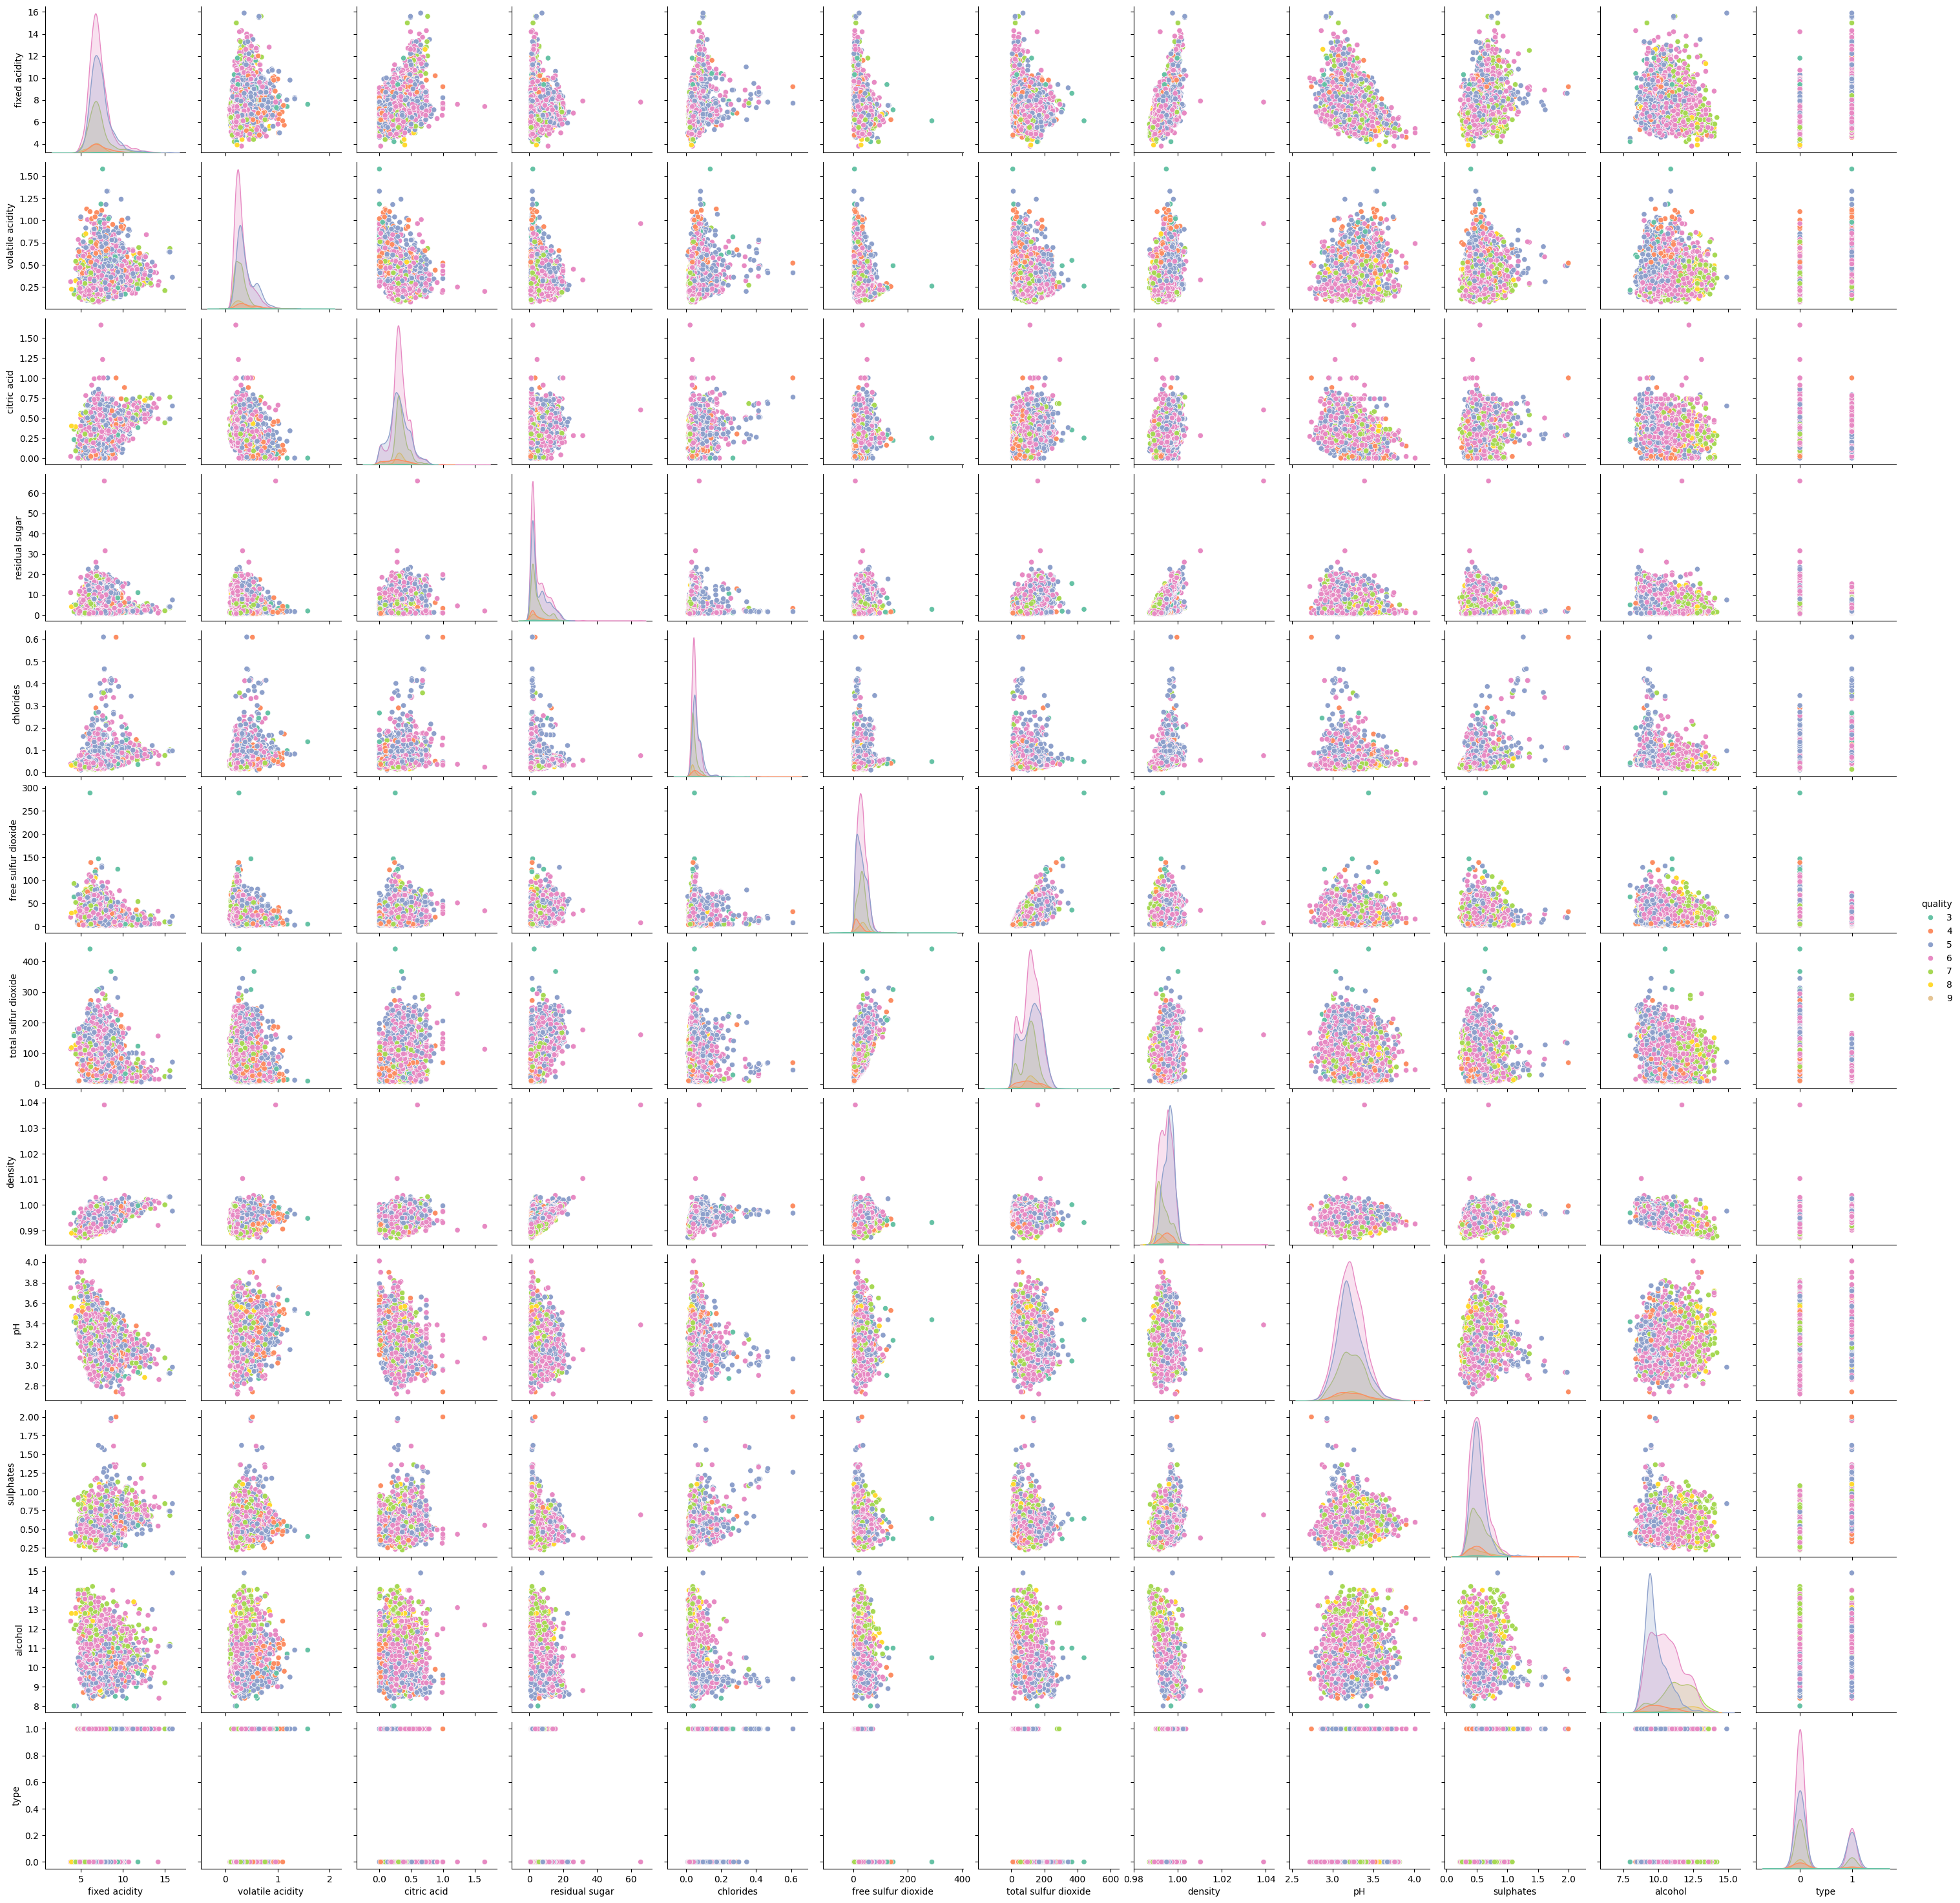

In [16]:
sns.pairplot(df, hue='quality',palette='Set2')
plt.show()

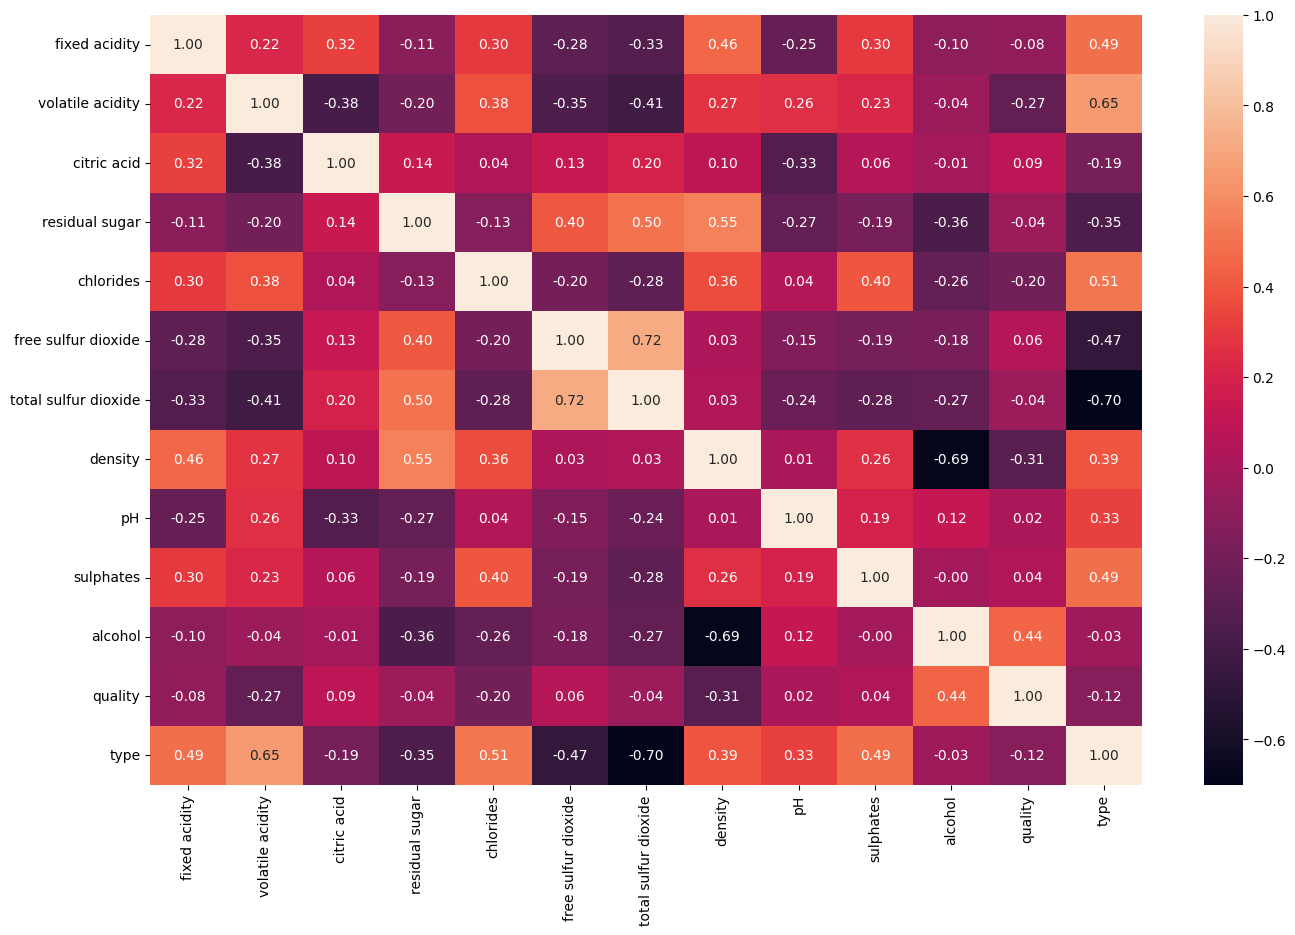

In [17]:

plt.figure(figsize=(16,10))
sns.heatmap(df.corr(method='pearson'), annot=True,fmt='.2f')
plt.show()

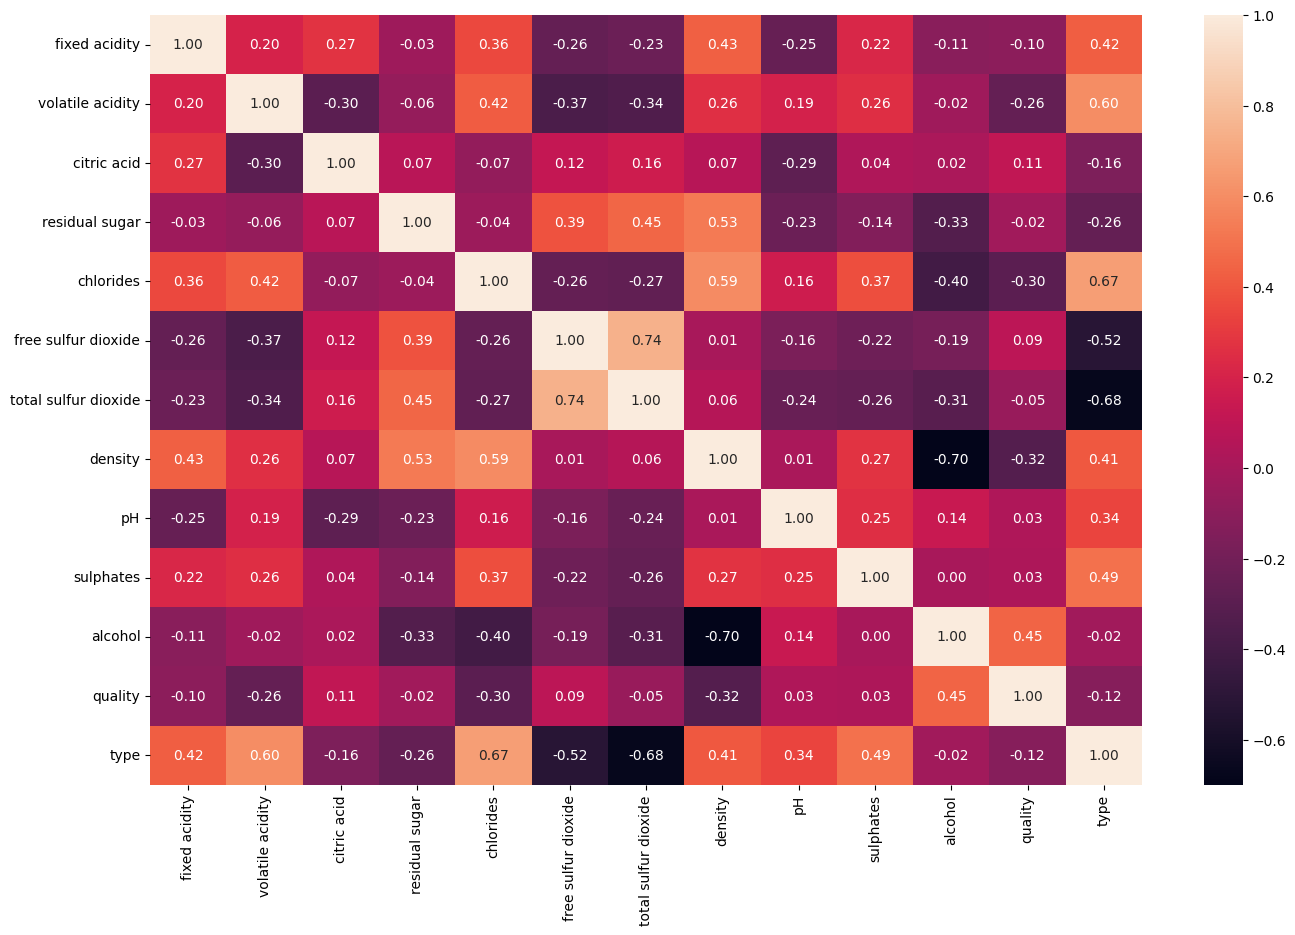

In [18]:
plt.figure(figsize=(16,10))
sns.heatmap(df.corr(method='spearman'), annot=True,fmt='.2f')
plt.show()

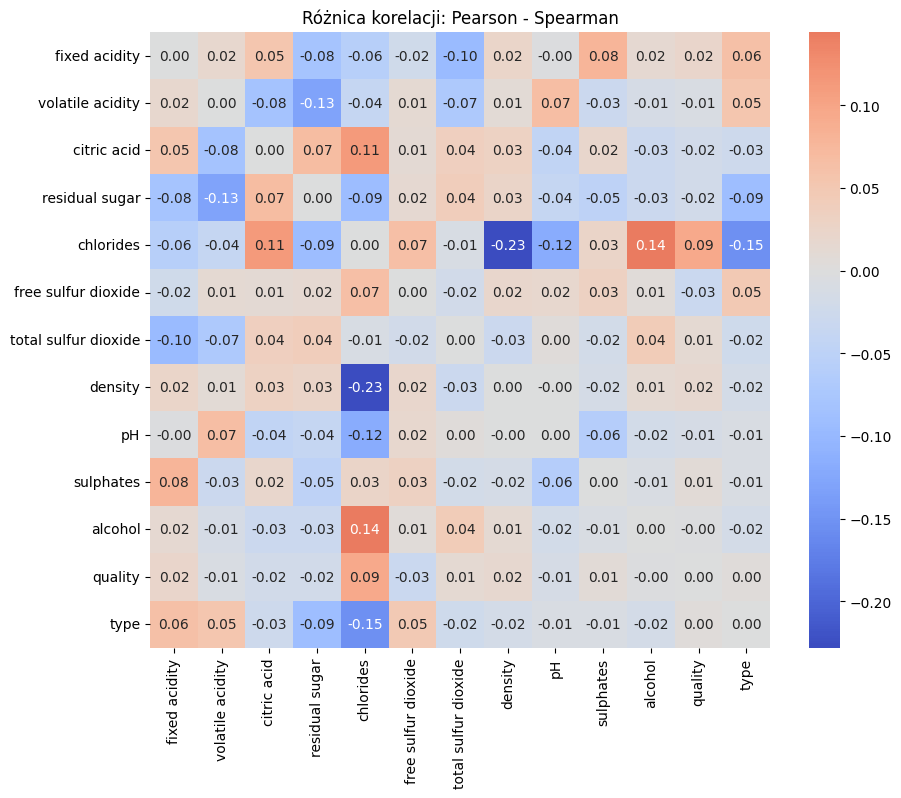

In [19]:
corr_pearson = df.corr(method='pearson')
corr_spearman = df.corr(method='spearman')
# policz różnicę
corr_diff = corr_pearson - corr_spearman
# narysuj heatmapę różnic
plt.figure(figsize=(10,8))
sns.heatmap(corr_diff, annot=True, cmap="coolwarm", center=0, fmt='.2f')
plt.title("Różnica korelacji: Pearson - Spearman")
plt.show()

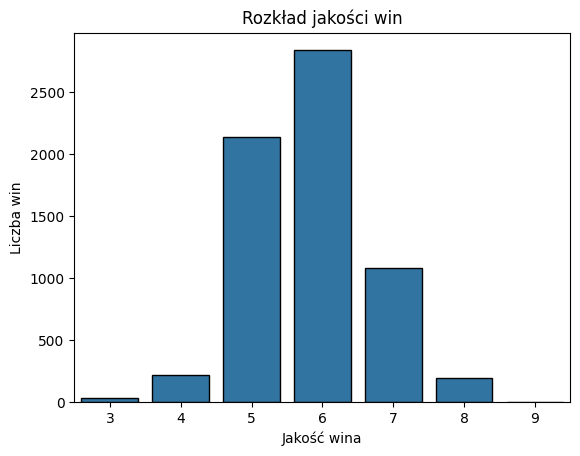

In [20]:
sns.countplot(x="quality", data=df, edgecolor="black")
plt.xlabel("Jakość wina")
plt.ylabel("Liczba win")
plt.title("Rozkład jakości win")
plt.show()

In [21]:
#badanie czy roskład jest normalny - nie jest normalny
from scipy.stats import shapiro
stat, p = shapiro(df["quality"])
print("Statystyka:", stat, "p-value:", p)
if p > 0.05:
    print("Nie odrzucamy hipotezy normalności – rozkład bliski normalnemu")
else:
    print("Odrzucamy hipotezę normalności – rozkład nie jest normalny")

Statystyka: 0.8841072016191466 p-value: 1.1388205246254468e-56
Odrzucamy hipotezę normalności – rozkład nie jest normalny


c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6497.
  res = hypotest_fun_out(*samples, **kwds)


In [22]:
#badanie skośności - <0 (ujemna): Rozkład ma lewostronną skośność.
#badanie kurtozy - <3 rozkład bardziej płaski od normalnego
# nie trzeba stosować transformacji do zmiennej
print(df["quality"].skew())
print(df["quality"].kurtosis())



0.18962269337269683
0.2323222693432636


In [23]:
X = df.drop(['quality'], axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [24]:
model = LinearRegression()
model.fit(X_train_sc, y_train)
# 2. Predykcja na zbiorze testowym
y_pred = model.predict(X_test_sc)
# 3. Ocena modelu
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2: {r2:.3f}")
# 4. Jeśli chcesz przewidzieć całkowite oceny wina
y_pred_rounded = np.clip(np.round(y_pred), 3, 9)  # zaokrąglamy i przycinamy do zakresu 3-9

MAE: 0.564
RMSE: 0.736
R2: 0.267


In [47]:


with open('linear_regression.pkl','wb') as f:
    pickle.dump(model,f)

# load
with open('linear_regression.pkl', 'rb') as f:
    clf2 = pickle.load(f)

In [25]:
#Wszystkie te trzy metryki dają pełniejszy obraz jakości Twojego modelu regresji.

#MAE i RMSE mówią o skali błędu, a różnica między nimi (0.736 vs 0.564) sugeruje, że w Twoich przewidywaniach występują duże błędy (skoro RMSE jest znacznie większe niż MAE).

#R² wskazuje, że model jest słaby i wyjaśnia tylko niewielką część danych. Być może potrzebujesz więcej danych, innych cech lub bardziej złożonego algorytmu.

In [26]:
# Zakładamy, że X_train_sc, X_test_sc, y_train, y_test są gotowe
# 1. Stworzenie modelu bazowego
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
# 2. Definicja siatki parametrów
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
# 3. GridSearch z 5-krotną walidacją krzyżową
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
# 4. Trenowanie
grid_search.fit(X_train_sc, y_train)
# 5. Najlepszy model i parametry
best_rf = grid_search.best_estimator_
print("Najlepsze parametry:", grid_search.best_params_)
print("Najlepszy wynik MSE (CV):", -grid_search.best_score_)
# 6. Predykcja i ocena na zbiorze testowym
y_pred = best_rf.predict(X_test_sc)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2: {r2:.3f}")
# 7. Zaokrąglanie do ocen całkowitych
y_pred_rounded = np.clip(np.round(y_pred), 3, 9)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Najlepsze parametry: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Najlepszy wynik MSE (CV): 0.3787831805442446
MAE: 0.436
RMSE: 0.607
R2: 0.502


In [45]:
import pickle

with open('random_forest_regression.pkl','wb') as f:
    pickle.dump(grid_search,f)

# load
with open('random_forest_regression.pkl', 'rb') as f:
    clf2 = pickle.load(f)


In [27]:
accuracy = np.mean(y_pred_rounded == y_test)
print(f"Dokładność przewidywania całkowitych ocen: {accuracy:.2%}")

Dokładność przewidywania całkowitych ocen: 67.54%


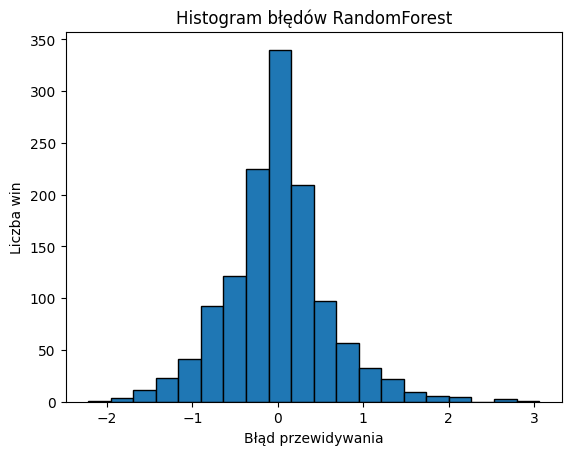

In [28]:
errors = y_pred - y_test
plt.hist(errors, bins=20, edgecolor='black')
plt.xlabel("Błąd przewidywania")
plt.ylabel("Liczba win")
plt.title("Histogram błędów RandomForest")
plt.show()

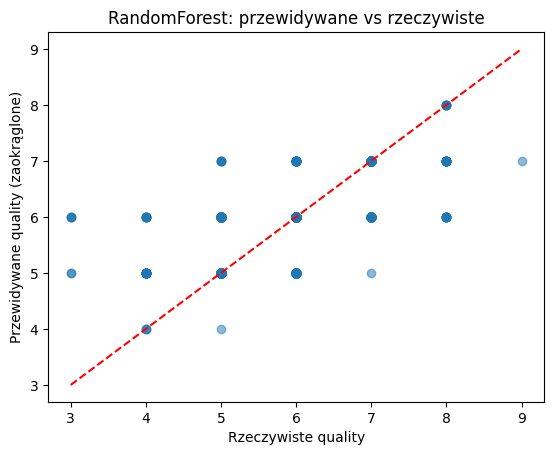

In [29]:
y_pred_rounded = np.clip(np.round(y_pred), 3, 9)
plt.scatter(y_test, y_pred_rounded, alpha=0.5)
plt.plot([3,9],[3,9], 'r--')
plt.xlabel("Rzeczywiste quality")
plt.ylabel("Przewidywane quality (zaokrąglone)")
plt.title("RandomForest: przewidywane vs rzeczywiste")
plt.show()

In [33]:
importances = best_rf.feature_importances_
# jeśli masz DataFrame
feature_names = X_train.columns
feat_importances = pd.Series(importances, index=feature_names)

C:\Users\pawel\AppData\Local\Temp\ipykernel_24932\2506750593.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


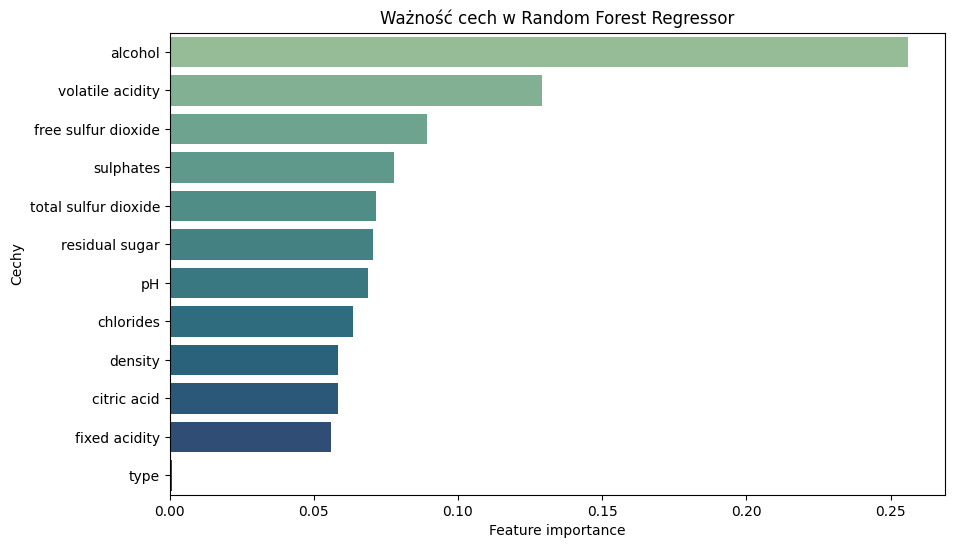

In [34]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=feat_importances.sort_values(ascending=False),
    y=feat_importances.sort_values(ascending=False).index,
    palette="crest"
)
plt.title("Ważność cech w Random Forest Regressor")
plt.xlabel("Feature importance")
plt.ylabel("Cechy")
plt.show()

In [48]:
grid_search_v2 = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
# 4. Trenowanie
grid_search_v2.fit(X_train_sc, y_train)
# 5. Najlepszy model i parametry
best_rf_v2 = grid_search_v2.best_estimator_
print("Najlepsze parametry:", grid_search_v2.best_params_)
print("Najlepszy wynik MSE (CV):", -grid_search_v2.best_score_)
# 6. Predykcja i ocena na zbiorze testowym
y_pred = best_rf_v2.predict(X_test_sc)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2: {r2:.3f}")
# 7. Zaokrąglanie do ocen całkowitych
y_pred_rounded = np.clip(np.round(y_pred), 3, 9)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Najlepsze parametry: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Najlepszy wynik MSE (CV): 0.4429867945016165
MAE: 0.436
RMSE: 0.607
R2: 0.502


In [50]:
results = []
results.append({
    "Model": "RandomForest_scoring_neg_mean_absolute_error",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})

In [49]:
# save
with open('random_forrest_regression_v2.pkl','wb') as f:
    pickle.dump(grid_search_v2,f)

# load
with open('random_forrest_regression_v2.pkl', 'rb') as f:
    clf2 = pickle.load(f)

Low sugar mean quality: 5.8075864178647905
High sugar mean quality: 5.829306071871128


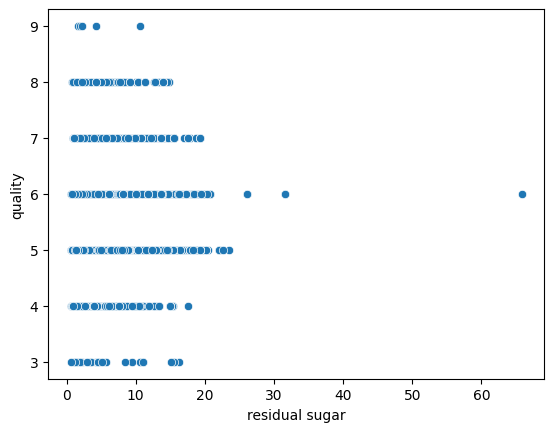

Korelacja sugar-quality: -0.036980484585769566


In [35]:
# 1. Średnie quality dla niskich i wysokich poziomów cukru
median_sugar = df['residual sugar'].median()
print("Low sugar mean quality:", df[df['residual sugar'] <= median_sugar]['quality'].mean())
print("High sugar mean quality:", df[df['residual sugar'] > median_sugar]['quality'].mean())
# 2. Scatterplot + korelacja
sns.scatterplot(x='residual sugar', y='quality', data=df)
plt.show()
print("Korelacja sugar-quality:", df[['residual sugar','quality']].corr().iloc[0,1])

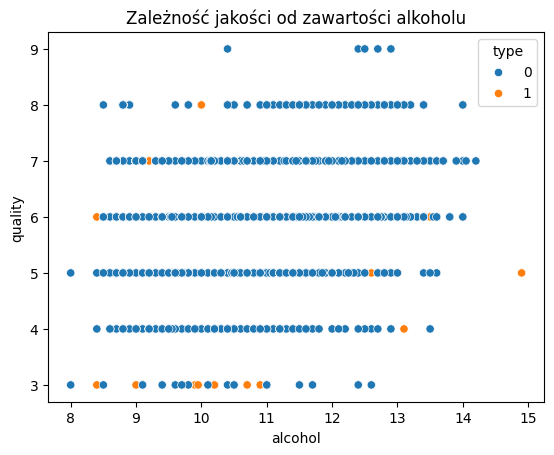

In [36]:
sns.scatterplot(x='alcohol', y='quality', data=df, hue='type')
plt.title("Zależność jakości od zawartości alkoholu")
plt.show()

In [ ]:
# --- Alcohol ---
median_alc = df['alcohol'].median()
print("Low alcohol mean quality:", df[df['alcohol'] <= median_alc]['quality'].mean())
print("High alcohol mean quality:", df[df['alcohol'] > median_alc]['quality'].mean())
print()

Low alcohol mean quality: 5.484673748103186
High alcohol mean quality: 6.161773891317926



In [38]:
# --- Volatile Acidity ---
median_va = df['volatile acidity'].median()
print("Low volatile acidity mean quality:", df[df['volatile acidity'] <= median_va]['quality'].mean())
print("High volatile acidity mean quality:", df[df['volatile acidity'] > median_va]['quality'].mean())
print()

Low volatile acidity mean quality: 5.967133292757151
High volatile acidity mean quality: 5.666147617564621



In [39]:
# --- pH ---
median_ph = df['pH'].median()
print("Low pH mean quality:", df[df['pH'] <= median_ph]['quality'].mean())
print("High pH mean quality:", df[df['pH'] > median_ph]['quality'].mean())

Low pH mean quality: 5.783992859268075
High pH mean quality: 5.855229591836735


In [41]:
cols = [c for c in df.columns if c not in ['quality', 'type']]  # pomijamy target i typ wina
for col in cols:
    median_val = df[col].median()
    low_mean = df[df[col] <= median_val]['quality'].mean()
    high_mean = df[df[col] > median_val]['quality'].mean()
    print(f"--- {col} ---")
    print(f"Low {col} mean quality: {low_mean:.2f}")
    print(f"High {col} mean quality: {high_mean:.2f}\n")

--- fixed acidity ---
Low fixed acidity mean quality: 5.89
High fixed acidity mean quality: 5.74

--- volatile acidity ---
Low volatile acidity mean quality: 5.97
High volatile acidity mean quality: 5.67

--- citric acid ---
Low citric acid mean quality: 5.76
High citric acid mean quality: 5.88

--- residual sugar ---
Low residual sugar mean quality: 5.81
High residual sugar mean quality: 5.83

--- chlorides ---
Low chlorides mean quality: 6.02
High chlorides mean quality: 5.61

--- free sulfur dioxide ---
Low free sulfur dioxide mean quality: 5.74
High free sulfur dioxide mean quality: 5.90

--- total sulfur dioxide ---
Low total sulfur dioxide mean quality: 5.85
High total sulfur dioxide mean quality: 5.78

--- density ---
Low density mean quality: 6.05
High density mean quality: 5.59

--- pH ---
Low pH mean quality: 5.78
High pH mean quality: 5.86

--- sulphates ---
Low sulphates mean quality: 5.80
High sulphates mean quality: 5.84

--- alcohol ---
Low alcohol mean quality: 5.48
Hig

In [42]:
corr_with_quality = df.drop(columns=['type']).corr()['quality'].drop('quality')
print(corr_with_quality.sort_values(ascending=False))

alcohol                 0.444319
citric acid             0.085532
free sulfur dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual sugar         -0.036980
total sulfur dioxide   -0.041385
fixed acidity          -0.076743
chlorides              -0.200666
volatile acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64


C:\Users\pawel\AppData\Local\Temp\ipykernel_24932\1074628091.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_quality.values, y=corr_with_quality.index, palette="coolwarm")


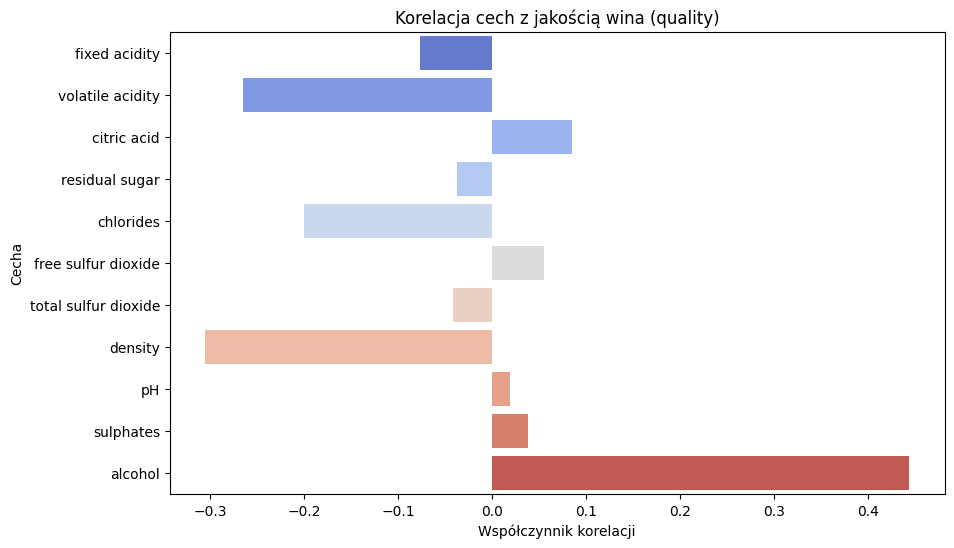

In [43]:
plt.figure(figsize=(10,6))
sns.barplot(x=corr_with_quality.values, y=corr_with_quality.index, palette="coolwarm")
plt.title("Korelacja cech z jakością wina (quality)")
plt.xlabel("Współczynnik korelacji")
plt.ylabel("Cecha")
plt.show()

Fitting 5 folds for each of 27 candidates, totalling 135 fits


c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Najlepsze parametry: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Najlepszy wynik (CV): 0.6692357666395201
Accuracy: 0.672
F1 (macro): 0.373

Raport klasyfikacji:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.75      0.07      0.13        43
           5       0.67      0.72      0.69       402
           6       0.66      0.76      0.71       597
           7       0.72      0.53      0.61       215
           8       1.00      0.31      0.47        36
           9       0.00      0.00      0.00         1

    accuracy                           0.67      1300
   macro avg       0.54      0.34      0.37      1300
weighted avg       0.68      0.67      0.66      1300



c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

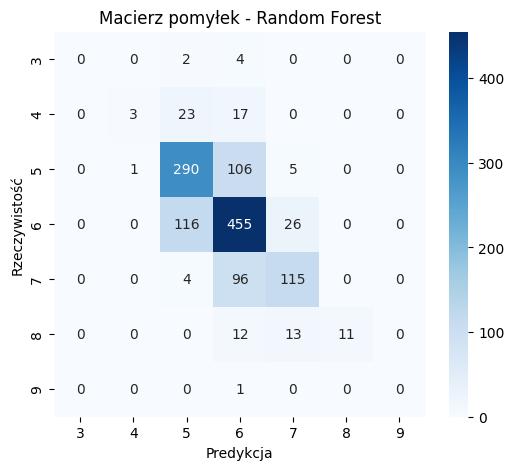

In [69]:


rf_v2 = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
}
grid_search_v3 = GridSearchCV(
    estimator=rf_v2,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",   # <- albo "f1_macro"
    n_jobs=-1,
    verbose=1
)
grid_search_v3.fit(X_train_sc, y_train)
best_rf_v3 = grid_search_v3.best_estimator_
print("Najlepsze parametry:", grid_search_v3.best_params_)
print("Najlepszy wynik (CV):", grid_search_v3.best_score_)

y_pred = best_rf_v3.predict(X_test_sc)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")  # dla wielu klas
print(f"Accuracy: {acc:.3f}")
print(f"F1 (macro): {f1:.3f}")
print("\nRaport klasyfikacji:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=best_rf_v3.classes_, yticklabels=best_rf_v3.classes_)
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywistość")
plt.title("Macierz pomyłek - Random Forest")
plt.show()



In [72]:
results.append({
    "Model": "RandomForest (Classification)",
    "Accuracy": acc,
    "F1": f1
})

In [74]:
# save
with open('RandomForestClassifier_accuracy.pkl','wb') as f:
    pickle.dump(grid_search_v3,f)

# load
with open('RandomForestClassifier_accuracy.pkl', 'rb') as f:
    clf2 = pickle.load(f)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Najlepsze parametry: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Najlepszy wynik (CV): 0.39600070057047754
Accuracy: 0.678
F1 (macro): 0.393

Raport klasyfikacji:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.67      0.14      0.23        43
           5       0.66      0.74      0.70       402
           6       0.67      0.75      0.71       597
           7       0.72      0.54      0.62       215
           8       0.92      0.33      0.49        36
           9       0.00      0.00      0.00         1

    accuracy                           0.68      1300
   macro avg       0.52      0.36      0.39      1300
weighted avg       0.68      0.68      0.67      1300



c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

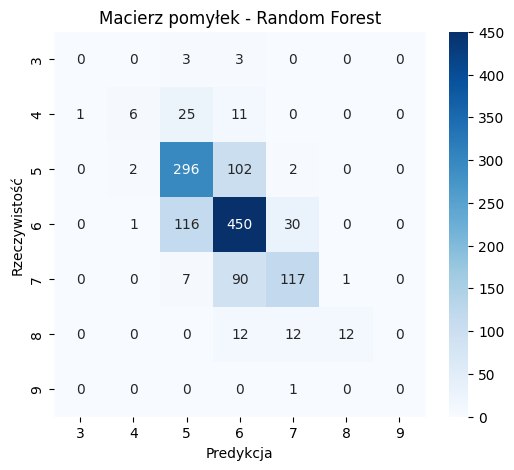

In [75]:


rf_v2 = RandomForestClassifier(random_state=42)



grid_search_v3 = GridSearchCV(
    estimator=rf_v2,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",   # <- albo "f1_macro"
    n_jobs=-1,
    verbose=1
)
grid_search_v3.fit(X_train_sc, y_train)
best_rf_v3 = grid_search_v3.best_estimator_
print("Najlepsze parametry:", grid_search_v3.best_params_)
print("Najlepszy wynik (CV):", grid_search_v3.best_score_)

y_pred = best_rf_v3.predict(X_test_sc)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")  # dla wielu klas
print(f"Accuracy: {acc:.3f}")
print(f"F1 (macro): {f1:.3f}")
print("\nRaport klasyfikacji:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=best_rf_v3.classes_, yticklabels=best_rf_v3.classes_)
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywistość")
plt.title("Macierz pomyłek - Random Forest")
plt.show()


In [76]:
results.append({
    "Model": "RandomForest (Classification_f1)",
    "Accuracy": acc,
    "F1": f1
})

In [77]:
# save
with open('RandomForestClassifier_f1_macro.pkl','wb') as f:
    pickle.dump(grid_search_v3,f)

# load
with open('RandomForestClassifier_f1_macro.pkl', 'rb') as f:
    clf2 = pickle.load(f)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [17:33:36] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Najlepsze parametry: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.7}
Najlepszy wynik CV (F1-macro): 0.39546203330389035
Accuracy: 0.670
F1-macro: 0.403
F1-weighted: 0.662

Raport klasyfikacji:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.69      0.21      0.32        43
           5       0.66      0.71      0.68       402
           6       0.67      0.74      0.71       597
           7       0.67      0.56      0.61       215
           8       0.81      0.36      0.50        36
           9       0.00      0.00      0.00         1

    accuracy                           0.67      1300
   macro avg       0.50      0.37      0.40      1300
weighted avg       0.67      0.67      0.66      1300



c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

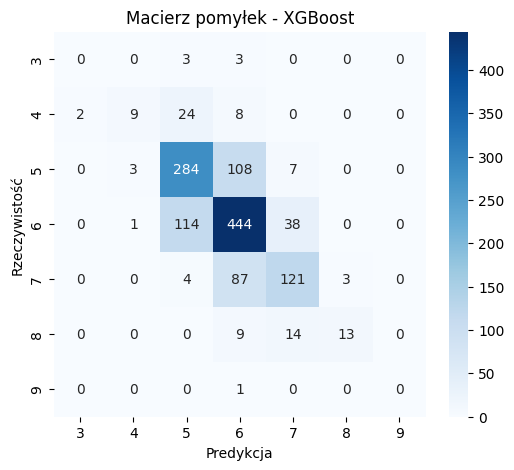

In [94]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
# --------------------------
# :three: Definicja modelu i GridSearchCV
# --------------------------
xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 1.0]
}
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)
# --------------------------
# :four: Trenowanie
# --------------------------
grid_search.fit(X_train_sc, y_train_enc)
best_xgb = grid_search.best_estimator_
print("Najlepsze parametry:", grid_search.best_params_)
print("Najlepszy wynik CV (F1-macro):", grid_search.best_score_)
# --------------------------
# :five: Predykcja na zbiorze testowym
# --------------------------
y_pred_enc = best_xgb.predict(X_test_sc)
# Przywrócenie oryginalnych klas
y_pred = le.inverse_transform(y_pred_enc)
# --------------------------
# :six: Ewaluacja
# --------------------------
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")
print(f"Accuracy: {acc:.3f}")
print(f"F1-macro: {f1_macro:.3f}")
print(f"F1-weighted: {f1_weighted:.3f}")
print("\nRaport klasyfikacji:\n", classification_report(y_test, y_pred))
# --------------------------
# :seven: Macierz pomyłek
# --------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywistość")
plt.title("Macierz pomyłek - XGBoost")
plt.show()

In [95]:
results.append({
    "Model": "XGBoost_f1",
    "Accuracy": acc,
    "F1-macro": f1_macro,
})

In [96]:
# save
with open('xgboost_f1_macro.pkl','wb') as f:
    pickle.dump(grid_search_v3,f)

# load
with open('xgboost_f1_macro.pkl', 'rb') as f:
    clf2 = pickle.load(f)

<Figure size 1000x600 with 0 Axes>

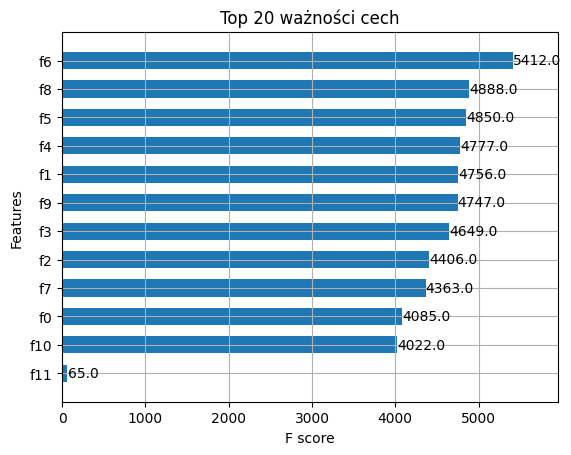

In [97]:
from xgboost import plot_importance
plt.figure(figsize=(10,6))
plot_importance(best_xgb, max_num_features=20, importance_type='weight', height=0.6)
plt.title("Top 20 ważności cech")
plt.show()

C:\Users\pawel\AppData\Local\Temp\ipykernel_24932\295958279.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette="viridis")


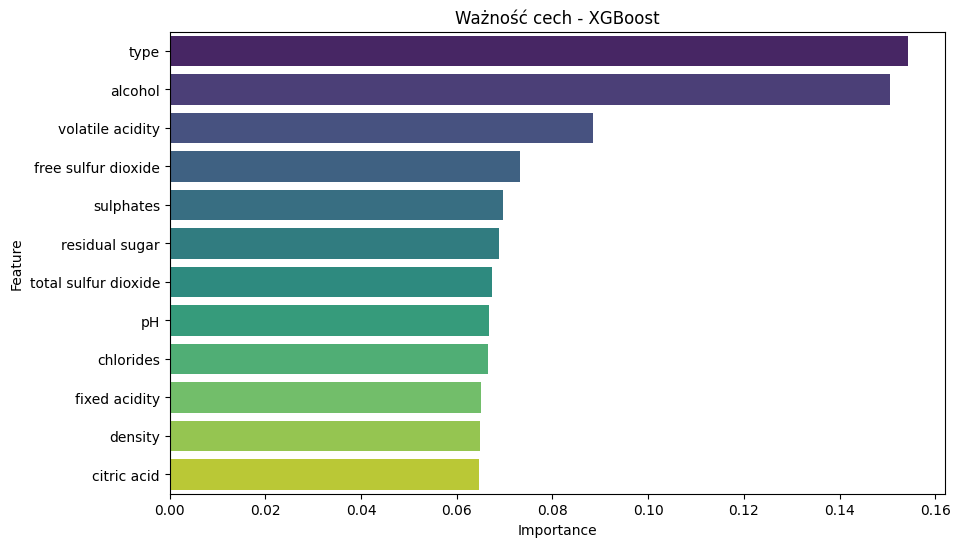

In [99]:
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'feat_{i}' for i in range(X_train.shape[1])]
# Wyciągnięcie ważności cech
importances = best_xgb.feature_importances_
# Posortowanie od największej
indices = np.argsort(importances)[::-1]
# Wykres
plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette="viridis")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Ważność cech - XGBoost")
plt.show()

Fitting 5 folds for each of 108 candidates, totalling 540 fits


c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [18:00:39] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Najlepsze parametry: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300, 'subsample': 1.0}
Najlepszy wynik CV (F1-macro): 0.3990037611492394
Accuracy: 0.635
F1-macro: 0.410
F1-weighted: 0.631

Raport klasyfikacji:
               precision    recall  f1-score   support

           3       0.33      0.17      0.22         6
           4       0.34      0.23      0.28        43
           5       0.65      0.72      0.68       402
           6       0.68      0.64      0.66       597
           7       0.55      0.60      0.57       215
           8       0.56      0.39      0.46        36
           9       0.00      0.00      0.00         1

    accuracy                           0.63      1300
   macro avg       0.44      0.39      0.41      1300
weighted avg       0.63      0.63      0.63      1300



c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

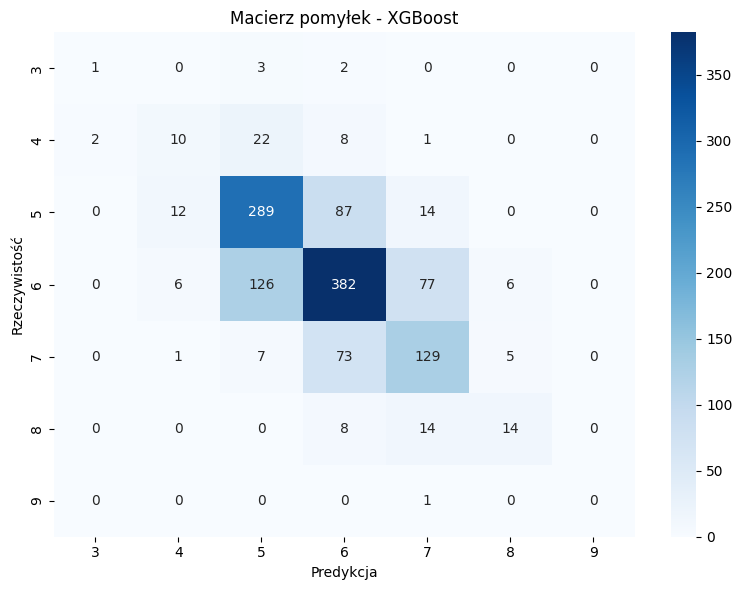

C:\Users\pawel\AppData\Local\Temp\ipykernel_24932\2845353435.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette="viridis")


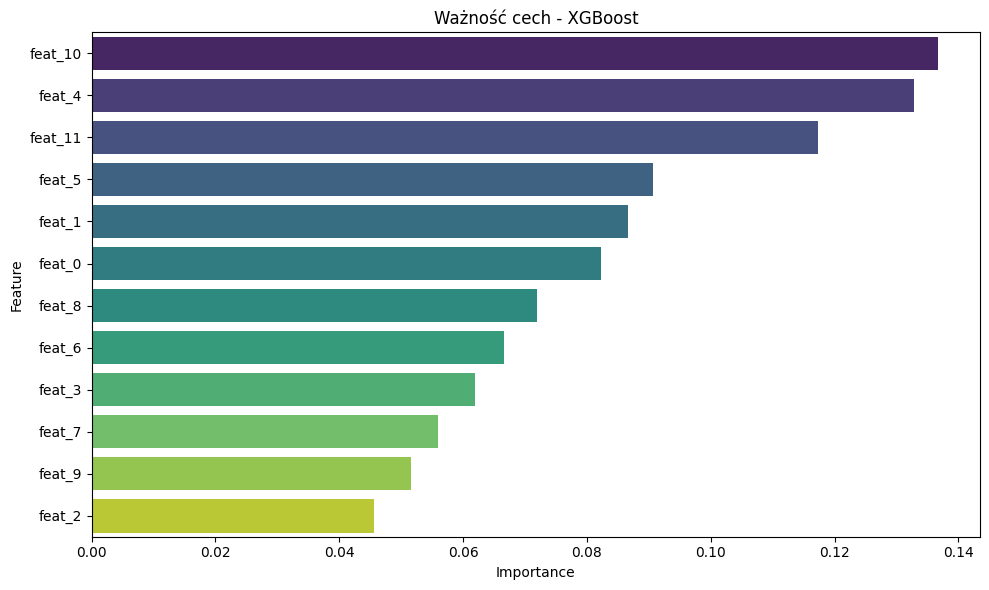

In [102]:
# LabelEncoder do mapowania klas na 0..n_classes-1
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
# --------------------------
# :three: Sample weights dla nierównych klas
# --------------------------
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
sample_weights = np.array([class_weights[c] for c in y_train])
# --------------------------
# :four: Definicja modelu i GridSearchCV
# --------------------------
xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0]
}
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)
# --------------------------
# :five: Trenowanie
# --------------------------
grid_search.fit(X_train_sc, y_train_enc, sample_weight=sample_weights)
best_xgb = grid_search.best_estimator_
print("Najlepsze parametry:", grid_search.best_params_)
print("Najlepszy wynik CV (F1-macro):", grid_search.best_score_)
# --------------------------
# :six: Predykcja i ewaluacja
# --------------------------
y_pred_enc = best_xgb.predict(X_test_sc)
y_pred = le.inverse_transform(y_pred_enc)
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")
print(f"Accuracy: {acc:.3f}")
print(f"F1-macro: {f1_macro:.3f}")
print(f"F1-weighted: {f1_weighted:.3f}")
print("\nRaport klasyfikacji:\n", classification_report(y_test, y_pred))
# --------------------------
# :seven: Macierz pomyłek
# --------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywistość")
plt.title("Macierz pomyłek - XGBoost")
plt.tight_layout()
plt.show()
# --------------------------
# :eight: Wykres ważności cech
# --------------------------
feature_names = X_train_sc.columns if hasattr(X_train_sc, 'columns') else [f'feat_{i}' for i in range(X_train_sc.shape[1])]
importances = best_xgb.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, max(6, len(feature_names)/2)))
sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette="viridis")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Ważność cech - XGBoost")
plt.tight_layout()
plt.show()

C:\Users\pawel\AppData\Local\Temp\ipykernel_24932\295958279.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette="viridis")


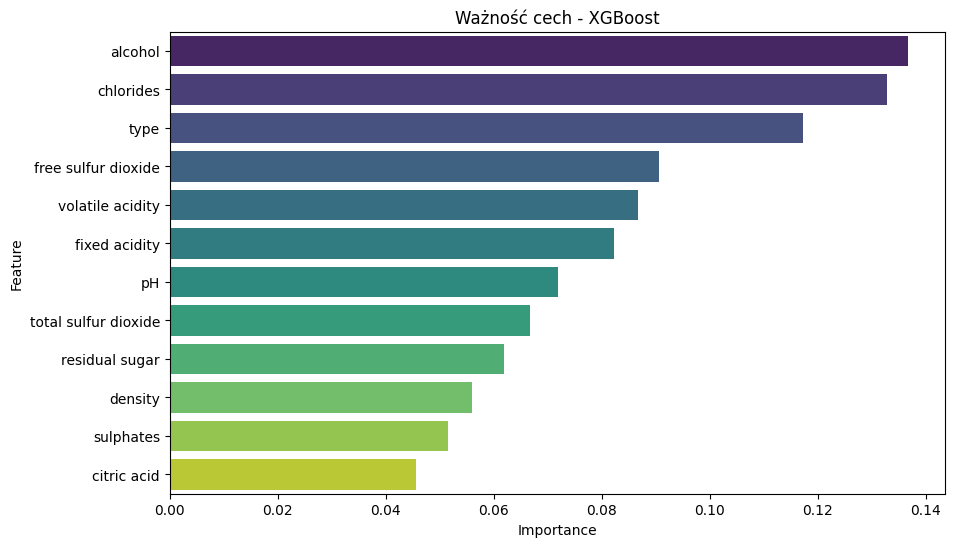

In [103]:
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'feat_{i}' for i in range(X_train.shape[1])]
# Wyciągnięcie ważności cech
importances = best_xgb.feature_importances_
# Posortowanie od największej
indices = np.argsort(importances)[::-1]
# Wykres
plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette="viridis")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Ważność cech - XGBoost")
plt.show()

In [104]:
results.append({
    "Model": "XGBoost_f1_scale_pos_weight",
    "Accuracy": acc,
    "F1-macro": f1_macro,
})

In [106]:
# save
with open('xgboost_f1_macro_scale_pos_weight.pkl','wb') as f:
    pickle.dump(grid_search_v3,f)

# load
with open('xgboost_f1_macro_scale_pos_weight.pkl', 'rb') as f:
    clf2 = pickle.load(f)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [18:57:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Najlepsze parametry: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100, 'subsample': 1.0}
Najlepszy wynik CV (F1-macro): 0.40288598039858925
Accuracy: 0.654
F1-macro: 0.431
F1-weighted: 0.650

Raport klasyfikacji:
               precision    recall  f1-score   support

           3       0.33      0.17      0.22         6
           4       0.46      0.26      0.33        43
           5       0.65      0.73      0.69       402
           6       0.69      0.65      0.67       597
           7       0.59      0.66      0.62       215
           8       0.64      0.39      0.48        36
           9       0.00      0.00      0.00         1

    accuracy                           0.65      1300
   macro avg       0.48      0.41      0.43      1300
weighted avg       0.65      0.65      0.65      1300



c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

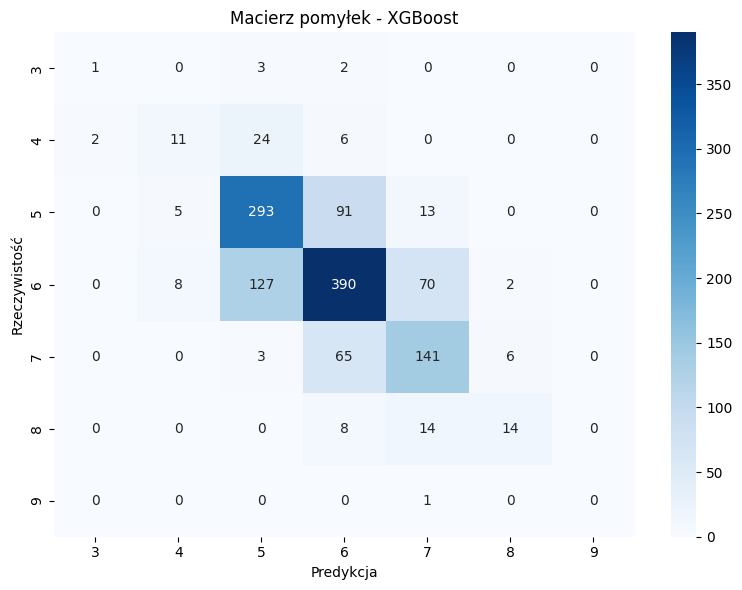

C:\Users\pawel\AppData\Local\Temp\ipykernel_24932\2444541485.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette="viridis")


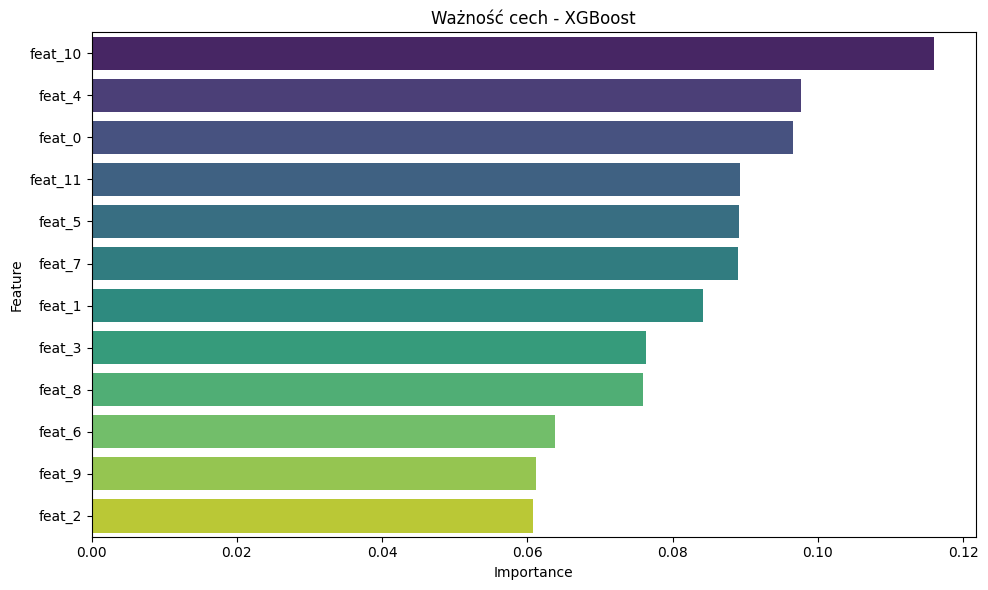

In [110]:
# LabelEncoder do mapowania klas na 0..n_classes-1
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
# --------------------------
# :three: Sample weights dla nierównych klas
# --------------------------
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
sample_weights = np.array([class_weights[c] for c in y_train])
# --------------------------
# :four: Definicja modelu i GridSearchCV
# --------------------------
xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
param_grid = {
    "n_estimators": [50, 100, 500],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.001, 0.01, 0.1, 1],
    "subsample": [0.2, 0.7, 1.0],
    "colsample_bytree": [0.2, 0.7, 1.0]
}
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)
# --------------------------
# :five: Trenowanie
# --------------------------
grid_search.fit(X_train_sc, y_train_enc, sample_weight=sample_weights)
best_xgb = grid_search.best_estimator_
print("Najlepsze parametry:", grid_search.best_params_)
print("Najlepszy wynik CV (F1-macro):", grid_search.best_score_)
# --------------------------
# :six: Predykcja i ewaluacja
# --------------------------
y_pred_enc = best_xgb.predict(X_test_sc)
y_pred = le.inverse_transform(y_pred_enc)
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")
print(f"Accuracy: {acc:.3f}")
print(f"F1-macro: {f1_macro:.3f}")
print(f"F1-weighted: {f1_weighted:.3f}")
print("\nRaport klasyfikacji:\n", classification_report(y_test, y_pred))
# --------------------------
# :seven: Macierz pomyłek
# --------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywistość")
plt.title("Macierz pomyłek - XGBoost")
plt.tight_layout()
plt.show()
# --------------------------
# :eight: Wykres ważności cech
# --------------------------
feature_names = X_train_sc.columns if hasattr(X_train_sc, 'columns') else [f'feat_{i}' for i in range(X_train_sc.shape[1])]
importances = best_xgb.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, max(6, len(feature_names)/2)))
sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette="viridis")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Ważność cech - XGBoost")
plt.tight_layout()
plt.show()

In [123]:
from imblearn.over_sampling import SMOTE
# Apply SMOTE to the training data
smote = SMOTE( random_state=42, k_neighbors=2)
X_resampled, y_resampled = smote.fit_resample(X_train_sc, y_train)
# Check the class distribution after applying SMOTE
print(pd.Series(y_resampled).value_counts())

c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


quality
5    2239
7    2239
6    2239
4    2239
8    2239
3    2239
9    2239
Name: count, dtype: int64


In [127]:
# Train the classifier on the SMOTE-balanced dataset
clf_smote = RandomForestClassifier(random_state=42)
clf_smote.fit(X_resampled, y_resampled)
# Predict on the test set
y_pred_smote = clf_smote.predict(X_test)
# Evaluate the model
print("Classification Report (After SMOTE):") 
print(classification_report(y_test, y_pred_smote))


Classification Report (After SMOTE):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        43
           5       0.62      0.02      0.05       402
           6       0.46      0.99      0.63       597
           7       0.00      0.00      0.00       215
           8       0.00      0.00      0.00        36
           9       0.00      0.00      0.00         1

    accuracy                           0.46      1300
   macro avg       0.16      0.14      0.10      1300
weighted avg       0.40      0.46      0.30      1300



c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metri

Fitting 5 folds for each of 54 candidates, totalling 270 fits


c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [19:32:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Najlepsze parametry: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.7}
Najlepszy wynik CV (F1-macro): 0.9035309396656925
Accuracy: 0.658
F1-macro: 0.423
F1-weighted: 0.657

Raport klasyfikacji:
               precision    recall  f1-score   support

           3       0.25      0.17      0.20         6
           4       0.33      0.33      0.33        43
           5       0.68      0.69      0.69       402
           6       0.68      0.70      0.69       597
           7       0.64      0.60      0.62       215
           8       0.50      0.39      0.44        36
           9       0.00      0.00      0.00         1

    accuracy                           0.66      1300
   macro avg       0.44      0.41      0.42      1300
weighted avg       0.66      0.66      0.66      1300



c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\pawel\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

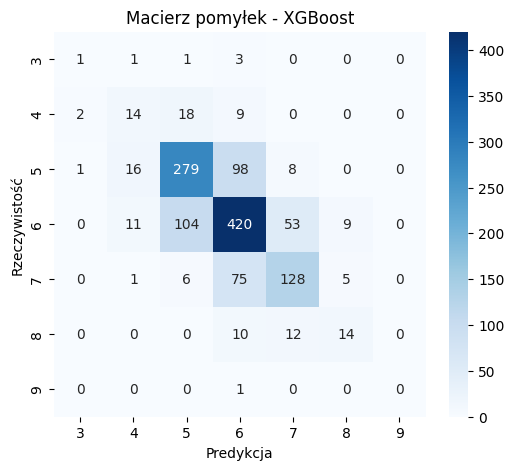

In [129]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_resampled)
y_test_enc = le.transform(y_test)
# --------------------------
# :three: Definicja modelu i GridSearchCV
# --------------------------
xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 1.0]
}
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)
# --------------------------
# :four: Trenowanie
# --------------------------
grid_search.fit(X_resampled, y_train_enc)
best_xgb = grid_search.best_estimator_
print("Najlepsze parametry:", grid_search.best_params_)
print("Najlepszy wynik CV (F1-macro):", grid_search.best_score_)
# --------------------------
# :five: Predykcja na zbiorze testowym
# --------------------------
y_pred_enc = best_xgb.predict(X_test_sc)
# Przywrócenie oryginalnych klas
y_pred = le.inverse_transform(y_pred_enc)
# --------------------------
# :six: Ewaluacja
# --------------------------
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")
print(f"Accuracy: {acc:.3f}")
print(f"F1-macro: {f1_macro:.3f}")
print(f"F1-weighted: {f1_weighted:.3f}")
print("\nRaport klasyfikacji:\n", classification_report(y_test, y_pred))
# --------------------------
# :seven: Macierz pomyłek
# --------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywistość")
plt.title("Macierz pomyłek - XGBoost")
plt.show()

In [4]:
le = LabelEncoder()
# save
with open('encoder_le.pkl','wb') as f:
    pickle.dump(le, f)

# load
with open('encoder_le.pkl', 'rb') as f:
    clf2 = pickle.load(f)